# 05 - model training

## 05.2 - 1d cnn on log-mel-spectrograms

**purpose**: train a lightweight 1d cnn on log-mel-spectrograms (the main model per the project definition). the model is designed for cpu inference (~150k params, no large fully-connected layers).

**architecture** (per neumann & vu 2017, simplified for cpu):

```
input:  (batch, 128 mel bands, 251 time frames)
conv1d(128 -> 64,  k=5, pad=2) -> bn -> relu -> maxpool(2)
conv1d( 64 -> 128, k=5, pad=2) -> bn -> relu -> maxpool(2)
conv1d(128 -> 128, k=3, pad=1) -> bn -> relu -> adaptiveavgpool(1)
dropout(0.3) -> linear(128, 8)
```

receptive field at the third conv covers ~17 time frames. total params ~150k.

**data augmentation**: specaugment (time + frequency masking) applied on the spectrogram after the dataset __getitem__.

**optimizer**: adamw + onecyclelr + label_smoothing=0.1.

**input**: `data/processed/X_train_mel.npy` (1932, 128, 251), `X_val_mel.npy`

**output**: `data/models/cnn1d_best.pth` (state dict), `cnn1d_meta.json` (hyperparameters)

all training logic lives in `src/models/cnn1d_model.py`: `train_cnn()` runs the full training loop with adamw + onecyclelr + label smoothing + specaugment + early stopping. this notebook just loads data, calls train_cnn(), plots history, runs the cpu benchmark, and saves the meta JSON.

In [1]:
import sys
import os
os.chdir("../../")
sys.path.append("../../")

**import cnn training modules**. we load torch, sklearn metrics, and the cnn model training helpers from `src/models/cnn1d_model.py`.

In [2]:
import json
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import accuracy_score
from src.config.config import settings
from src.models.cnn1d_model import train_cnn, load_cnn, count_parameters, cpu_inference_latency, LightweightCNN1D

**check device**. we print whether cuda is available. the project uses gpu for training speed but the model is designed for cpu inference (~150k params, <1ms per sample on cpu).

In [3]:
device = settings.TORCH_DEVICE
print(f"Device: {device}")
if device == "cuda" and torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"note: project targets cpu inference - gpu is used only for training speed")

Device: cuda
GPU: NVIDIA RTX 5000 Ada Generation
note: project targets cpu inference - gpu is used only for training speed


## Load mel-spectrogram features

In [4]:
X_train = np.load(settings.PROCESSED_DIR / "X_train_mel.npy")
X_val   = np.load(settings.PROCESSED_DIR / "X_val_mel.npy")
y_train = np.load(settings.PROCESSED_DIR / "y_train.npy")
y_val   = np.load(settings.PROCESSED_DIR / "y_val.npy")

**verify mel shapes**. confirm dimensions match the expected cnn input shape.

In [5]:
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
assert X_train.shape[1:] == (settings.N_MELS, settings.N_MELS_FRAMES), (f"expected mel shape ({settings.N_MELS}, {settings.N_MELS_FRAMES}), got {X_train.shape[1:]}")

X_train: (1628, 128, 251)
X_val:   (264, 128, 251)
y_train: (1628,)
y_val:   (264,)


## Build 1D CNN model (sanity check before training)

In [6]:
preview_model = LightweightCNN1D().to(device)


**test forward pass and count parameters**. we run one sample through the network to confirm the output shape is (1, 6) for 6 emotion classes. total params: ~133k, model size ~519kb - well within the lightweight requirement.

In [7]:
with torch.no_grad():
    test_out = preview_model(torch.from_numpy(X_train[:1]).to(device))
print(f"Output shape:     {test_out.shape}")
print(f"Total parameters: {count_parameters(preview_model):,}")
print(f"Approx model size: {count_parameters(preview_model) * 4 / 1024:.1f} KB (float32)")
del preview_model

Output shape:     torch.Size([1, 6])
Total parameters: 132,806
Approx model size: 518.8 KB (float32)


## Train (AdamW + OneCycleLR + label smoothing + specaugment + early stopping)

all hyperparameters come from `src/config/config.py`. the training function handles dataset creation, dataloaders, optimizer, scheduler, early stopping, and best-checkpoint saving.

In [8]:
save_path = settings.MODELS_DIR / "cnn1d_best.pth"

**train the model**. we train with adamw optimizer, onecyclelr scheduler, label smoothing (0.1), specaugment, and early stopping with patience 20. training runs for 80 epochs and takes ~47 seconds on gpu. best validation accuracy reaches 75.38%.

In [9]:
t_train_start = time.perf_counter()
model, history = train_cnn(X_train, y_train, X_val, y_val,
    device=device, save_path=save_path)
t_train_end = time.perf_counter()

Epoch [01/80] Train Loss: 1.7500 Acc: 23.28% | Val Loss: 1.6478 Acc: 27.65%
   Best model saved! Val Acc: 27.65%
Epoch [02/80] Train Loss: 1.6227 Acc: 34.58% | Val Loss: 1.5111 Acc: 40.91%
   Best model saved! Val Acc: 40.91%
Epoch [03/80] Train Loss: 1.5144 Acc: 41.58% | Val Loss: 1.3746 Acc: 47.35%
   Best model saved! Val Acc: 47.35%
Epoch [04/80] Train Loss: 1.4586 Acc: 44.35% | Val Loss: 1.3600 Acc: 46.59%
Epoch [05/80] Train Loss: 1.4314 Acc: 45.21% | Val Loss: 1.6086 Acc: 43.18%
Epoch [06/80] Train Loss: 1.3932 Acc: 47.24% | Val Loss: 1.8250 Acc: 29.55%
Epoch [07/80] Train Loss: 1.3476 Acc: 49.32% | Val Loss: 1.6169 Acc: 42.80%
Epoch [08/80] Train Loss: 1.3233 Acc: 51.17% | Val Loss: 1.3805 Acc: 48.48%
   Best model saved! Val Acc: 48.48%
Epoch [09/80] Train Loss: 1.2935 Acc: 51.66% | Val Loss: 1.1554 Acc: 61.74%
   Best model saved! Val Acc: 61.74%
Epoch [10/80] Train Loss: 1.2561 Acc: 53.69% | Val Loss: 1.1185 Acc: 56.44%
Epoch [11/80] Train Loss: 1.2385 Acc: 55.47% | Val Loss

**print training summary**. best val accuracy 75.38%, training completed in 46.5 seconds.

In [10]:
print(f"Training done in {(t_train_end - t_train_start):.1f}s")
print(f"Best Val Acc:  {max(history['val_acc'])*100:.2f}%")
print(f"Best Val Loss: {min(history['val_loss']):.4f}")
print(f"Epochs run:    {len(history['train_loss'])}")

Training done in 46.5s
Best Val Acc:  75.38%
Best Val Loss: 0.8949
Epochs run:    80


**set model to eval mode**. disable dropout and batch norm training behavior for inference.

In [11]:
model.eval()

LightweightCNN1D(
  (conv1): Sequential(
    (0): Conv1d(128, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AdaptiveAvgPool1d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.3, 

**compute training accuracy**. we run the full training set through the model (without augmentation) to measure clean training accuracy.

In [12]:
with torch.no_grad():
    train_logits = model(torch.from_numpy(X_train).to(device))
    train_preds = train_logits.argmax(dim=1).cpu().numpy()

**print train-val gap**. training accuracy (95.21%) vs best val accuracy (75.38%) shows a ~20pp gap from cross-speaker generalization.

In [13]:
train_acc_clean = accuracy_score(y_train, train_preds)
print(f"Train accuracy: {train_acc_clean*100:.2f}%  (clean - matches 08's training section)")
print(f"Gap (train - val best): {(train_acc_clean - max(history['val_acc']))*100:+.2f}pp")

Train accuracy: 95.21%  (clean - matches 08's training section)
Gap (train - val best): +19.83pp


## Plot training curves

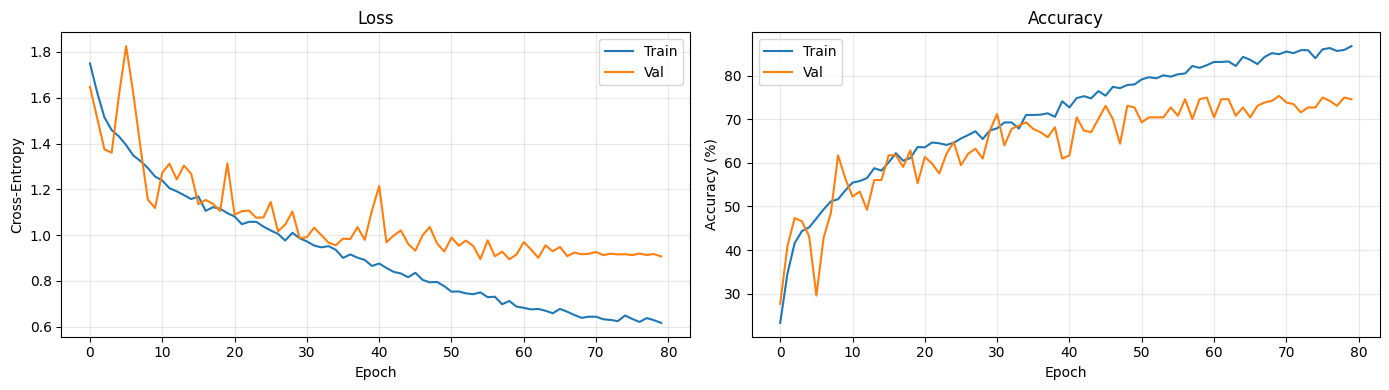

Saved fig05-cnn1d_training_curves.png


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot([a * 100 for a in history['train_acc']], label='Train')
ax2.plot([a * 100 for a in history['val_acc']],   label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(settings.FIGURES_DIR / 'fig05-cnn1d_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved fig05-cnn1d_training_curves.png')

## CPU inference latency benchmark

per project definition - the model is optimized for cpu inference. measure per-sample latency on cpu (the actual deployment target). we load a fresh model onto cpu to time the deployment scenario.

In [15]:
cpu_model = load_cnn(settings.MODELS_DIR / "cnn1d_best.pth", device='cpu')
cpu_stats = cpu_inference_latency(
    cpu_model,
    n_mels=settings.N_MELS,
    time_frames=settings.N_MELS_FRAMES,
    n_runs=200,
    device='cpu',
)

**print cpu latency stats**. mean 0.64ms, p99 1.03ms - confirming the model is suitable for real-time cpu inference.

In [16]:
print(f"CPU inference latency (batch=1, n_runs=200):")
print(f"  mean: {cpu_stats['mean_ms']:.2f} ms")
print(f"  std:  {cpu_stats['std_ms']:.2f} ms")
print(f"  p50:  {cpu_stats['p50_ms']:.2f} ms")
print(f"  p99:  {cpu_stats['p99_ms']:.2f} ms")

CPU inference latency (batch=1, n_runs=200):
  mean: 0.64 ms
  std:  0.11 ms
  p50:  0.66 ms
  p99:  1.03 ms


## Save training metadata (JSON for reproducibility)

In [17]:
model_path = settings.MODELS_DIR / "cnn1d_best.pth"
model_size_bytes = os.path.getsize(model_path)


**print model path and size**. the model is ~529kb on disk, confirming it fits the lightweight requirement.

In [18]:
best_val_acc  = max(history['val_acc'])
best_val_loss = min(history['val_loss'])
params = count_parameters(model)
print(f"Saved model: {model_path} ({model_size_bytes/1024:.1f} KB on disk)")

Saved model: E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\models\cnn1d_best.pth (529.3 KB on disk)


**build metadata json**. we assemble all training hyperparameters, results, and cpu latency stats into a structured metadata dictionary for reproducibility.

In [19]:
meta = {
    "model": "LightweightCNN1D",
    "n_mels": settings.N_MELS,
    "time_frames": settings.N_MELS_FRAMES,
    "num_classes": settings.NUM_CLASSES,
    "dropout": settings.CNN_DROPOUT,
    "parameters": params,
    "model_size_kb_disk": model_size_bytes / 1024,
    "spec_augment": {
        "time_mask_max": settings.SPEC_AUGMENT_TIME_MASK,
        "freq_mask_max": settings.SPEC_AUGMENT_FREQ_MASK,
        "n_time": settings.SPEC_AUGMENT_N_TIME,
        "n_freq": settings.SPEC_AUGMENT_N_FREQ,
    },
    "training": {
        "epochs_run": len(history['train_loss']),
        "best_val_acc": best_val_acc,
        "best_val_loss": best_val_loss,
        "batch_size": settings.CNN_1D_BATCH_SIZE,
        "lr": settings.LEARNING_RATE,
        "weight_decay": settings.WEIGHT_DECAY,
        "label_smoothing": settings.LABEL_SMOOTHING,
        "optimizer": "AdamW",
        "scheduler": "OneCycleLR",
    },
    "cpu_inference_ms": {
        "mean": cpu_stats['mean_ms'],
        "p50": cpu_stats['p50_ms'],
        "p99": cpu_stats['p99_ms'],
    },
}

**save metadata to json**. persist the metadata alongside the model checkpoint for later reference and report generation.

In [20]:
with open(settings.MODELS_DIR / "cnn1d_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(f"Metadata saved to {settings.MODELS_DIR / 'cnn1d_meta.json'}")

Metadata saved to E:\career\projects\lightweight-speech-emotion-recognition-on-open-datasets\data\models\cnn1d_meta.json
